# <u>**Câmera Estéreo**</u>

**<u>Integrantes</u>**

- Gabriel Intackli Pinto - 11201921426

- Lucas Medeiros da Silva - 11202130277

- Samira Haddad - 11201812350

**Data de Realização dos Experimentos**:

08/07/2026

**Data de Publicação do Relatório**

13/07/2026

## <u>Introdução</u>

Este relatório aborda o desenvolvimento, calibração e análise de um sistema de câmera estereoscópica de baixo custo. O objetivo do experimento consiste em compreender na prática os fundamentos da estereoscopia e da geometria epipolar, replicando a capacidade de perceção de profundidade biológica através de duas webcams USB fixadas paralelamente com base na distância inter-pupilar.

A visão estéreo fundamenta-se na busca de correspondências entre duas imagens distintas do mesmo cenário. Através do processo de calibração estéreo, determinam-se os parâmetros intrínsecos e extrínsecos do arranjo (representados pelas matrizes de projeção e a matriz fundamental), permitindo a retificação das imagens e o cálculo da disparidade. Ao longo deste documento, serão detalhados os procedimentos de montagem da estrutura física rígida, a execução dos scripts de calibração matemática via OpenCV e a geração final de imagens e vídeos 3D no formato anaglifo (vermelho/ciano). Por fim, são discutidos os resultados obtidos, confrontando a perceção visual gerada em tempo real com as gravações processadas.

## <u>Fundamentação Teórica</u>

### **Definições necessárias**
A seguir, iremos dispor alguns conceitos que são basilares para fundamentar o que iremos realizar neste experimento. A compreensão da geometria formada por múltiplas vistas e dos processos de correção de imagem é essencial para a montagem e utilização de um sistema de câmeras estéreo capaz de estimar profundidade.


#### **Epipolos, o plano epipolar, e a linha epipolar**
A geometria epipolar fundamenta-se em conceitos matemáticos que descrevem a relação geométrica entre duas câmeras, simplificando significativamente a busca por correspondências entre imagens estéreo (SADEKAR, 2020). No centro desta teoria encontram-se os epípolos, que são os pontos de interseção entre a linha que une os centros ópticos de ambas as câmeras (conhecida como baseline ou linha de base) e os respectivos planos de imagem. Em outras palavras, o epípolo representa a projeção do centro óptico de uma câmera no plano de imagem da outra.

O plano epipolar, por sua vez, é o plano tridimensional formado por um ponto qualquer observado na cena 3D e pelos dois centros ópticos das câmeras. A interseção deste plano tridimensional com o plano de imagem de cada câmera gera a chamada linha epipolar. A importância prática e computacional desta linha reside no fato de que, ao procurar a correspondência de um ponto da imagem esquerda na imagem direita, o algoritmo restringe a busca bidimensional para uma busca unidimensional ao longo dessa linha epipolar correspondente (SZELISKI, 2021, cap. 12).

##### **Matriz fundamental da câmera**
Para modelar matematicamente essa relação geométrica epipolar entre duas vistas, sem a necessidade prévia de conhecer a estrutura da cena tridimensional, utiliza-se a matriz fundamental (SADEKAR, 2020). Essa matriz de dimensão $3 \times 3$ atua como um operador algébrico que mapeia um ponto em uma imagem para sua correspondente linha epipolar na outra imagem. <br>
Os parâmetros que compõem a matriz fundamental dependem estritamente da calibração das câmeras e da posição relativa do par estéreo (SZELISKI, 2021, cap. 11). Ela engloba: <br>
* **Parâmetros intrínsecos:** representados pelas matrizes de calibração individuais de cada câmera, que contêm dados internos como a distância focal, o centro óptico (ponto principal) e os coeficientes de distorção da lente;
* **Parâmetros extrínsecos:** que definem a orientação espacial do sistema, isto é, a matriz de rotação e o vetor de translação relativa entre as duas câmeras.

##### **Disparidade estéreo**
A disparidade estéreo é definida como a diferença na coordenada horizontal (medida em pixels) de um mesmo ponto da cena quando projetado nas imagens esquerda e direita, após o processo de retificação (SADEKAR, 2020).

Como as câmeras estão montadas no mesmo plano, mas separadas por uma distância horizontal física, objetos que estão localizados mais próximos ao sistema exibem um deslocamento horizontal muito maior entre as imagens (alta disparidade). Em contrapartida, objetos localizados a grandes distâncias apresentam pouca ou nenhuma diferença de posição (baixa disparidade). Dessa forma, a disparidade é uma métrica inversamente proporcional à profundidade real da cena, sendo o principal parâmetro utilizado na visão computacional para o cálculo de mapas de profundidade (SZELISKI, 2021, cap. 12).

##### **Calibração Geométrica e Distorção de Lentes**
Para extrair informações métricas precisas e estimar a profundidade a partir de um par estéreo, é imprescindível realizar primeiramente a calibração geométrica intrínseca das câmeras (SZELISKI, 2021, cap. 11). Na prática, sistemas ópticos reais utilizam lentes que invariavelmente introduzem aberrações, sendo a mais significativa a distorção radial, fenômeno que faz com que linhas retas no mundo real pareçam curvadas, especialmente nas bordas da imagem capturada (SZELISKI, 2021, cap. 11).O processo de calibração permite estimar não apenas os parâmetros intrínsecos básicos da câmera — como a distância focal e as coordenadas do centro óptico —, mas também os coeficientes matemáticos dessa distorção (SADEKAR, 2021). De posse desses dados, o sistema pode aplicar uma transformação corretiva nas imagens, "desentortando-as" e garantindo que o modelo pinhole (câmera escura) assumido pela geometria epipolar seja válido para os cálculos subsequentes.

##### **Retificação Estéreo**
Mesmo com as câmeras calibradas e cientes de suas posições relativas (parâmetros extrínsecos), procurar pontos correspondentes ao longo de linhas epipolares arbitrárias e inclinadas na imagem é uma tarefa computacionalmente custosa. Para solucionar isso, aplica-se o processo de retificação estéreo (SZELISKI, 2021, cap. 12).A retificação consiste em reprojetar matematicamente as duas imagens originais sobre um plano de imagem comum, simulando uma configuração ideal onde os sensores das duas câmeras estariam perfeitamente coplanares e com seus eixos ópticos estritamente paralelos (SZELISKI, 2021, cap. 12). A grande vantagem desse procedimento é que as linhas epipolares passam a ser perfeitamente horizontais (colineares) em ambas as vistas (SADEKAR, 2020). Consequentemente, a busca por correspondência de um ponto coordenado em $(x, y)$ na imagem esquerda restringe-se apenas à mesma linha $y$ na imagem direita (buscando-se apenas um $x - d$, onde $d$ é a disparidade), simplificando o problema e acelerando algoritmos de correspondência densa.

## <u>Procedimentos Experimentais</u>



(B) Execute o exemplo com as imagens fornecidas:
- Calibração estéreo - python3 calibrate.py
- Geração e apresentação de imagem 3D - python3 movie3d.py

<u>Responda</u>: consulte a teoria da calibração e correção de distorção e o exemplo executado, e
com isso descreva todos os parametros necessários para a camera estéreo. Há algum arquivo necessário ?


Sim, existem arquivos estritamente necessários para o funcionamento deste pipeline:

1.**Arquivo de Parâmetros de Calibração (`.xml` ou `.yaml`):** O script de calibração (`calibrate.py`) não apenas calcula as matrizes descritas acima, mas as **salva em um arquivo de parâmetros**. O script subsequente de geração do vídeo 3D (`movie3d.py`) é programado para ler esse arquivo. Sem ele, o programa de visualização 3D não saberia como corrigir e alinhar as imagens ao vivo.

2.**Pares de Imagens de Calibração:**
Para que o `calibrate.py` possa gerar o arquivo XML, ele precisa obrigatoriamente consumir as pastas de imagens contendo os vários pares (esquerda e direita) de fotos do tabuleiro de xadrez em diversas posições.

---
(C) Execute a Calibração da sua câmera estéreo (construída com as webcams) pela captura de suas
próprias imagens de calibração e imagens de teste: Utilize o mesmo padrão de calibração a aula
anterior, e modifique os programas dos códigos de exemplo, adequando para os nossos
experimentos.

## Código executado

### capture_images_abc.py


In [ ]:
import cv2
import os

# ==========================================
# CONFIGURAÇÕES DA EQUIPE
# ==========================================
NOME_ALUNO = "lucas_medeiros"
MAX_IMAGENS = 15

output_path = "data_teste/"
os.makedirs(output_path + 'stereoL', exist_ok=True)
os.makedirs(output_path + 'stereoR', exist_ok=True)

# IDs das câmeras
CamL_id = 1
CamR_id = 0

print(f"Tentando conectar nas câmeras {CamL_id} e {CamR_id}...")
CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

# Forçando resolução baixa para não travar a porta USB
CamL.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
CamL.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
CamR.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
CamR.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not CamL.isOpened() or not CamR.isOpened():
    print("ERRO: Uma ou ambas as câmeras não abriram. Mude os IDs (0, 1, 2...).")
    exit(-1)

print("\n=== INSTRUÇÕES ===")
print("1. Posicione o tabuleiro de xadrez para que apareça NAS DUAS câmeras.")
print("2. Pressione a tecla 'S' (na janela do vídeo) para SALVAR o par de fotos.")
print("3. Pressione a tecla 'ESC' para sair.")
print("==================\n")

count = 0

while True:
    retR, frameR = CamR.read()
    retL, frameL = CamL.read()

    if not retR or not retL:
        print("Erro ao ler o frame das câmeras. Verifique os cabos USB.")
        break

    imgL_vis = frameL.copy()
    imgR_vis = frameR.copy()

    cv2.putText(imgL_vis, f"Fotos salvas: {count}/{MAX_IMAGENS}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(imgL_vis, "Aperte 'S' para salvar", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    # Mostra os vídeos
    cv2.imshow('Camera ESQUERDA (L)', imgL_vis)
    cv2.imshow('Camera DIREITA (R)', imgR_vis)

    # Aguarda a tecla do usuário
    key = cv2.waitKey(1) & 0xFF

    # Se apertar 'S' (ou 's'), salva a foto
    if key == ord('s') or key == ord('S'):
        count += 1
        nome_img_R = f"{output_path}stereoR/{NOME_ALUNO}_R_{count}.png"
        nome_img_L = f"{output_path}stereoL/{NOME_ALUNO}_L_{count}.png"

        cv2.imwrite(nome_img_R, frameR)
        cv2.imwrite(nome_img_L, frameL)

        print(f"[{count}/{MAX_IMAGENS}] Foto salva com sucesso!")

        cv2.rectangle(imgL_vis, (0,0), (640,480), (0, 255, 0), 10)
        cv2.rectangle(imgR_vis, (0,0), (640,480), (0, 255, 0), 10)
        cv2.imshow('Camera ESQUERDA (L)', imgL_vis)
        cv2.imshow('Camera DIREITA (R)', imgR_vis)
        cv2.waitKey(200) # Pausa rápida

    # Encerra se atingir o limite
    if count >= MAX_IMAGENS:
        print(f"\nPerfeito! {MAX_IMAGENS} pares de fotos capturados.")
        break

    # Se apertar ESC, sai
    if key == 27:
        print("\nCaptura encerrada pelo usuário.")
        break

CamL.release()
CamR.release()
cv2.destroyAllWindows()

### calibrate_abc.py

In [ ]:
import numpy as np
import cv2
from tqdm import tqdm
import os

# ==========================================
# CONFIGURAÇÕES
# ==========================================
NOME_ALUNO = "lucas_medeiros"
CHECKERBOARD = (6, 8)
MAX_IMAGENS = 15

# Set the path to the images captured by the left and right cameras
pathL = "data_teste/stereoL/"
pathR = "data_teste/stereoR/"

print("Extracting image coordinates of respective 3D pattern ....\n")

# Termination criteria for refining the detected corners
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Cria a malha de pontos 3D baseada no tamanho do tabuleiro
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

img_ptsL = []
img_ptsR = []
obj_pts = []

for i in tqdm(range(1, MAX_IMAGENS + 1)):
    imgL_path = f"{pathL}{NOME_ALUNO}_L_{i}.png"
    imgR_path = f"{pathR}{NOME_ALUNO}_R_{i}.png"

    # Pula se o arquivo não existir
    if not os.path.exists(imgL_path) or not os.path.exists(imgR_path):
        continue

    imgL = cv2.imread(imgL_path)
    imgR = cv2.imread(imgR_path)
    imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    outputL = imgL.copy()
    outputR = imgR.copy()

    retR, cornersR = cv2.findChessboardCorners(outputR, CHECKERBOARD, None)
    retL, cornersL = cv2.findChessboardCorners(outputL, CHECKERBOARD, None)

    if retR and retL:
        obj_pts.append(objp)
        cv2.cornerSubPix(imgR_gray, cornersR, (11,11), (-1,-1), criteria)
        cv2.cornerSubPix(imgL_gray, cornersL, (11,11), (-1,-1), criteria)

        img_ptsL.append(cornersL)
        img_ptsR.append(cornersR)


print("\nCalculating left camera parameters ... ")
retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(obj_pts, img_ptsL, imgL_gray.shape[::-1], None, None)
hL, wL = imgL_gray.shape[:2]
new_mtxL, roiL = cv2.getOptimalNewCameraMatrix(mtxL, distL, (wL,hL), 1, (wL,hL))

print("Calculating right camera parameters ... ")
retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(obj_pts, img_ptsR, imgR_gray.shape[::-1], None, None)
hR, wR = imgR_gray.shape[:2]
new_mtxR, roiR = cv2.getOptimalNewCameraMatrix(mtxR, distR, (wR,hR), 1, (wR,hR))


print("Stereo calibration .....")
flags = 0
flags |= cv2.CALIB_FIX_INTRINSIC

criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

retS, new_mtxL, distL, new_mtxR, distR, Rot, Trns, Emat, Fmat = cv2.stereoCalibrate(
    obj_pts, img_ptsL, img_ptsR, new_mtxL, distL, new_mtxR, distR,
    imgL_gray.shape[::-1], criteria_stereo, flags)

rectify_scale = 1
rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR = cv2.stereoRectify(
    new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, rectify_scale, (0,0))

Left_Stereo_Map = cv2.initUndistortRectifyMap(new_mtxL, distL, rect_l, proj_mat_l, imgL_gray.shape[::-1], cv2.CV_16SC2)
Right_Stereo_Map = cv2.initUndistortRectifyMap(new_mtxR, distR, rect_r, proj_mat_r, imgR_gray.shape[::-1], cv2.CV_16SC2)

print("\n--- RESULTADOS PARA O RELATÓRIO ---")
print("Matriz de Rotação (Rot):\n", Rot)
print("\nVetor de Translação (Trns):\n", Trns)
print("\nMatriz Essencial (Emat):\n", Emat)
print("\nMatriz Fundamental (Fmat):\n", Fmat)
print("-----------------------------------\n")

print("Saving parameters ......")
xml_path = f"data_teste/params_{NOME_ALUNO}.xml"
cv_file = cv2.FileStorage(xml_path, cv2.FILE_STORAGE_WRITE)
cv_file.write("Left_Stereo_Map_x", Left_Stereo_Map[0])
cv_file.write("Left_Stereo_Map_y", Left_Stereo_Map[1])
cv_file.write("Right_Stereo_Map_x", Right_Stereo_Map[0])
cv_file.write("Right_Stereo_Map_y", Right_Stereo_Map[1])
cv_file.release()
print(f"Salvo com sucesso em {xml_path}")

### movie3d_abc.py

In [ ]:
import numpy as np
import cv2
import time
import threading

# ==========================================
# CLASSE DE CAPTURA PARALELA (ANTI-ATRASO)
# ==========================================
class CamStream:
    def __init__(self, src=0):
        self.stream = cv2.VideoCapture(src)

        self.stream.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        self.stream.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

        self.stream.set(cv2.CAP_PROP_BUFFERSIZE, 1)

        (self.grabbed, self.frame) = self.stream.read()
        self.stopped = False

    def start(self):
        threading.Thread(target=self.update, args=(), daemon=True).start()
        return self

    def update(self):
        while True:
            if self.stopped:
                self.stream.release()
                return
            (self.grabbed, self.frame) = self.stream.read()

    def read(self):
        return self.grabbed, self.frame

    def stop(self):
        self.stopped = True

# ==========================================
# CONFIGURAÇÕES DA EQUIPE
# ==========================================
NOME_ALUNO = "lucas_medeiros"
TEMPO_GRAVACAO = 15 # Segundos

print("Iniciando as câmeras em paralelo (Multi-threading)...")
CamL = CamStream(1).start()
CamR = CamStream(0).start()

time.sleep(1.0)

print("Lendo parâmetros do arquivo XML ...")
xml_path = f"data_teste/params_{NOME_ALUNO}.xml"
cv_file = cv2.FileStorage(xml_path, cv2.FILE_STORAGE_READ)

Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
cv_file.release()

output_video_path = f"data_teste/video3D_{NOME_ALUNO}.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 30.0
out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (700, 700))

print(f"\nIniciando visualização e gravação 3D ao vivo por {TEMPO_GRAVACAO} segundos!")
start_time = time.time()

while True:
    retR, imgR = CamR.read()
    retL, imgL = CamL.read()

    if retL and retR:
        # Aplica os mapas de correção
        Left_nice = cv2.remap(imgL, Left_Stereo_Map_x, Left_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
        Right_nice = cv2.remap(imgR, Right_Stereo_Map_x, Right_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

        # GERAÇÃO DO ANÁGLIFO (Vermelho + Ciano)
        output = Right_nice.copy()
        output[:,:,0] = Right_nice[:,:,0]
        output[:,:,1] = Right_nice[:,:,1]
        output[:,:,2] = Left_nice[:,:,2]

        output_resized = cv2.resize(output, (700, 700))

        tempo_decorrido = time.time() - start_time
        tempo_restante = max(0, TEMPO_GRAVACAO - int(tempo_decorrido))

        out_video.write(output_resized)

        cv2.putText(output_resized, f"Gravando: {tempo_restante}s", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        cv2.namedWindow("3D movie Live", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("3D movie Live", 700, 700)
        cv2.imshow("3D movie Live", output_resized)

        if tempo_decorrido >= TEMPO_GRAVACAO:
            print(f"\nGravação concluída com sucesso! Salvo em: {output_video_path}")
            break

        if cv2.waitKey(1) & 0xFF == 27:
            print("\nProcesso interrompido pelo usuário.")
            break
    else:
        print("Erro na captura das câmeras.")
        break


CamL.stop()
CamR.stop()
out_video.release()
cv2.destroyAllWindows()

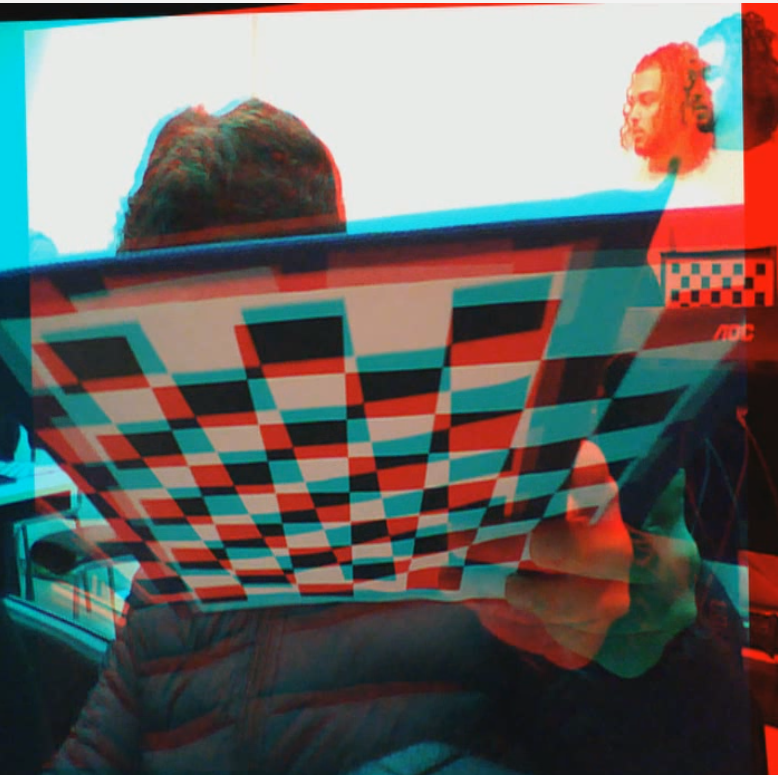

## <u>Análise e Discussão dos Estudos</u>


### Parâmetros e Valores da Câmera Estéreo

A partir da calibração conjunta das duas câmeras (esquerda e direita), o algoritmo `cv2.stereoCalibrate` calculou a relação geométrica tridimensional entre elas. Os parâmetros obtidos para o nosso sistema foram:

**1. Matriz de Rotação ($R$)**
Descreve a rotação matemática necessária para alinhar o sistema de coordenadas da câmera direita em relação à câmera esquerda:
$$R = \begin{bmatrix} 0.99720143 & 0.02220405 & 0.0713883 \\ -0.02091762 & 0.99960597 & -0.01871771 \\ -0.07177578 & 0.01717205 & 0.99727296 \end{bmatrix}$$

**2. Vetor de Translação ($t$)**
Representa o deslocamento físico (translação) do centro óptico da câmera direita em relação à câmera esquerda:
$$t = \begin{bmatrix} 0.80010537 \\ 0.0073863 \\ 0.04033414 \end{bmatrix}$$

**3. Matriz Essencial ($E$)**
Contém as informações geométricas sobre a translação e a rotação, relacionando as coordenadas dos pontos nas duas câmeras no sistema de coordenadas normalizado:
$$E = \begin{bmatrix} 3.13536811 \times 10^{-4} & -4.01914116 \times 10^{-2} & 8.12111987 \times 10^{-3} \\ 9.76494479 \times 10^{-2} & -1.28438692 \times 10^{-2} & -7.95044061 \times 10^{-1} \\ -2.41019280 \times 10^{-2} & 7.99626096 \times 10^{-1} & -1.55034337 \times 10^{-2} \end{bmatrix}$$

**4. Matriz Fundamental ($F$)**
Relaciona os pixels de uma imagem com as linhas epipolares correspondentes na outra imagem, atuando em coordenadas de pixel (em vez de coordenadas normalizadas como a Matriz Essencial):
$$F = \begin{bmatrix} 1.32142634 \times 10^{-7} & -1.70099771 \times 10^{-5} & 5.99962465 \times 10^{-3} \\ 4.13044724 \times 10^{-5} & -5.45555838 \times 10^{-6} & -2.44465736 \times 10^{-1} \\ -1.60900077 \times 10^{-2} & 2.38232896 \times 10^{-1} & 1.00000000 \end{bmatrix}$$

<br>


### Análise do Arquivo de Calibração (.xml)

**Nenhum dos parâmetros brutos listados acima ($R$, $t$, $E$, $F$) foi salvo diretamente no arquivo XML de saída (`params_lucas_medeiros.xml`).** **Justificativa:** Em sistemas de processamento de vídeo estéreo em tempo real, calcular o remapeamento e a retificação de cada frame a partir dessas matrizes brutas geraria um custo computacional muito alto. Portanto, o código utiliza esses parâmetros brutos para pré-calcular os **Mapas Densos de Retificação e Distorção**.

O que é efetivamente salvo no arquivo XML são essas matrizes de mapeamento, prontas para serem consumidas pela função `cv2.remap()`:
* `Left_Stereo_Map_x` e `Left_Stereo_Map_y`
* `Right_Stereo_Map_x` e `Right_Stereo_Map_y`

Elas agem como "tabelas de busca" (lookup tables), informando ao algoritmo exatamente para qual coordenada cada pixel da imagem original deve ser movido para que ambas as imagens fiquem perfeitamente alinhadas horizontalmente, garantindo o funcionamento correto do efeito estereoscópico.

#### **Desempenho da percepção de profundidade**

Durante a etapa final do experimento, todos os integrantes da equipe realizaram a visualização do vídeo final utilizando os óculos 3D com lentes anáglifas (vermelho e ciano). Constatamos que foi possível perceber o efeito de profundidade na cena.

A ilusão tridimensional funcionou, sendo o efeito de "relevo" e volume especialmente evidente nos objetos posicionados mais próximos às lentes e nos elementos de maior contraste. Embora as limitações de hardware das webcams e a iluminação do laboratório tenham gerado alguns ruídos visuais, o alinhamento das imagens retificadas pela nossa calibração estéreo provou-se suficiente para recriar a disparidade visual, permitindo que o cérebro interpretasse a terceira dimensão (eixo Z) no vídeo gravado.






## <u>Conclusão</u>



A realização deste laboratório permitiu a compreensão prática de um dos conceitos mais fascinantes da Visão Computacional: a estereoscopia. Desde a montagem física do suporte com materiais recicláveis até a superação dos desafios de sincronização de hardware (FPS e *delay* das portas USB), o experimento demonstrou que a extração de profundidade a partir de duas lentes exige um rigor geométrico e computacional altíssimo. A calibração bem-sucedida e a geração do vídeo 3D em anáglifo comprovaram a eficácia das matrizes matemáticas ($R$, $t$, $E$, $F$) e dos mapas de retificação na correção e alinhamento do mundo real.

#### Análise de Aplicação da Câmera Estéreo no Trabalho Final

O nosso Trabalho Final da disciplina consistirá no desenvolvimento de uma aplicação de **Detecção Facial utilizando Redes Neurais Convolucionais (CNNs)**.

Analisando os requisitos técnicos desse projeto, concluímos que **não há necessidade de aplicação da câmera estéreo construída neste laboratório**. A justificativa técnica baseia-se na própria natureza das arquiteturas de CNN focadas em detecção de objetos/faces (como YOLO, SSD ou MTCNN). Esses algoritmos são projetados e treinados para extrair *features* espaciais bidimensionais (bordas, texturas, contrastes e padrões geométricos do rosto) a partir de matrizes de pixels 2D (imagens RGB ou em escala de cinza).

A introdução de um sistema estéreo traria uma complexidade computacional (necessidade de processar dois fluxos de vídeo, retificar imagens em tempo real e calcular mapas de disparidade) sem agregar um ganho real para a tarefa principal, que já é resolvida com alta precisão por uma única câmera (monocular).

#### Melhorias Futuras

Considerando as dificuldades práticas enfrentadas durante a execução do experimento, elencamos as seguintes melhorias para futuras iterações da construção de câmeras estéreo:

* **Upgrade de Hardware (Resolução e Sincronização):** A utilização de webcams de baixo custo e baixa resolução limitou a nitidez da imagem final e dificultou a detecção precisa dos cantos do tabuleiro pelo algoritmo. Câmeras com resoluções maiores (HD ou Full HD) e com suporte nativo a sincronização de obturador (*hardware sync*) eliminariam o problema de *delay* entre os quadros e gerariam matrizes de calibração muito mais precisas.
* **Aprimoramento da Estrutura Física (Rigidez):** A estrutura construída com materiais recicláveis (caixas de papelão/placas) cumpre o papel didático, mas é suscetível a micro-vibrações. Como a calibração estéreo depende de uma matriz extrínseca imutável, qualquer esbarrão milimétrico na estrutura invalida os parâmetros matemáticos ($R$ e $t$). A fabricação de um suporte rígido, por exemplo utilizando impressão 3D ou hastes de metal com parafusos de fixação, garantiria que as lentes nunca saíssem do alinhamento epipolar ideal.

## <u>Referências</u>

#### Nota a respeito do uso de IA generativa
Em consonância com a norma com a portaria 2664/2026 da Cnpq, declaramos que durante o desenvolvimento deste trabalho, foram utilizadas ferramentas de inteligência artificial generativa de forma auxiliar. O assistente ChatGPT GPT-4o e Gemini 2.5 Flash foi empregado para revisão ortográfica e gramatical e formatação de referências bibliográficas. Todo o conteúdo intelectual, a análise crítica, a interpretação dos dados e as conclusões são de autoria exclusiva dos discentes. As saídas das ferramentas de IA foram integralmente revisadas e reescritas pelo autor antes da incorporação ao texto.

<br><br>

SZELISKI, R. Structure from motion and SLAM. In: SZELISKI, R. Computer Vision: Algorithms and Applications. 2. ed. (final draft). [S. l.: s. n.], 2021. cap. 11.

SZELISKI, R. Depth estimation. In: SZELISKI, R. Computer Vision: Algorithms and Applications. 2. ed. (final draft). [S. l.: s. n.], 2021. cap. 12.

SADEKAR, K. Introduction to Epipolar Geometry and Stereo Vision. LearnOpenCV, 28 dez. 2020. Disponível em: https://learnopencv.com/introduction-to-epipolar-geometry-and-stereo-vision/. Acesso em: 8 jul. 2026.

SADEKAR, K. Making A Low-Cost Stereo Camera Using OpenCV. LearnOpenCV, 11 jan. 2021. Disponível em: https://learnopencv.com/making-a-low-cost-stereo-camera-using-opencv/. Acesso em: 8 jul. 2026.